# Battery State of Health (SOH) Prediction using Machine Learning

## 1. Problem Definition

The objective of this project is to develop a machine learning model that predicts the **State of Health (SOH)** of lithium-ion batteries using cycle-level battery data. Accurate SOH prediction helps monitor battery degradation, optimize maintenance schedules, improve battery management systems (BMS), and extend battery lifespan in applications such as electric vehicles and energy storage systems.

## 2. Data

The dataset used in this project contains **1,415 battery cycle records** collected from lithium-ion batteries. Each record includes battery operating parameters such as battery ID, cycle number, voltage, temperature, capacity, State of Health (SOH), and Remaining Useful Life (RUL).

## 3. Evaluation

Since this is a regression problem, the model performance will be evaluated using the following metrics:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score (Coefficient of Determination)

The objective is to minimize MAE and RMSE while maximizing the R² Score.

## 4. Features

The dataset contains the following features:

- **battery_id** – Unique identifier for each battery
- **cycle** – Charge/discharge cycle number
- **voltage** – Battery voltage
- **temperature** – Battery temperature
- **capacity** – Measured battery capacity
- **soh** – State of Health (Target Variable)
- **rul** – Remaining Useful Life

Target Variable:
- **soh**

## 5. Modelling

The following machine learning regression models will be trained and compared:

- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor
- Gradient Boosting Regressor
- XGBoost Regressor 

The model with the best performance based on evaluation metrics will be selected.

## 6. Experimentation

Different preprocessing techniques, feature selections, and hyperparameter tuning methods will be explored to improve model performance. GridSearchCV or RandomizedSearchCV will be used for hyperparameter optimization, and cross-validation will be performed to ensure the model generalizes well to unseen data.

In [1]:
# Import tools that we need

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

# Models from Scikit-Learn
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Model Selection
from sklearn.model_selection import train_test_split, cross_val_score

# Evaluation Matrics
from sklearn.metrics import (
     mean_absolute_error,
     mean_squared_error,
     r2_score
)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Set plotting style
plt.style.use("ggplot")

## Load The Dataset

In [2]:
df = pd.read_csv("data/battery_cycle_level_dataset_CLEAN_FINAL.csv")
df.head()

,battery_id,cycle,voltage,temperature,capacity,soh,rul
0,B0005,1,3.532781,32.536891,1.861976,1.000000,167
1,B0005,2,3.542968,32.643595,1.851862,0.994568,166
2,B0005,3,3.553056,32.522526,1.840808,0.988631,165
3,B0005,4,3.545849,32.492083,1.850058,0.993599,164
4,B0005,5,3.544456,32.368612,1.849432,0.993263,163


In [3]:
df.shape

(1415, 7)

In [4]:
df.tail()

,battery_id,cycle,voltage,temperature,capacity,soh,rul
1410,B0053,54,3.080080,12.530864,1.292799,0.988320,1
1411,B0053,55,3.063813,12.900294,1.312809,1.003617,0
1412,B0054,1,3.205983,12.489230,0.853855,1.000000,0
1413,B0055,1,3.153346,12.207199,0.854758,1.000000,0
1414,B0056,1,3.241611,10.334364,0.794083,1.000000,0


In [5]:
df.columns

Index(['battery_id', 'cycle', 'voltage', 'temperature', 'capacity', 'soh',
       'rul'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1415 entries, 0 to 1414
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   battery_id   1415 non-null   str    
 1   cycle        1415 non-null   int64  
 2   voltage      1415 non-null   float64
 3   temperature  1415 non-null   float64
 4   capacity     1415 non-null   float64
 5   soh          1415 non-null   float64
 6   rul          1415 non-null   int64  
dtypes: float64(4), int64(2), str(1)
memory usage: 77.5 KB


In [7]:
df.describe()

,cycle,voltage,temperature,capacity,soh,rul
count,1415.000000,1415.000000,1415.000000,1415.000000,1415.000000,1415.000000
mean,55.389399,3.420612,26.589773,1.501191,0.849014,54.175972
std,42.728497,0.166460,13.196045,0.316995,0.119219,43.709204
min,1.000000,2.530010,7.684550,0.520105,0.604449,0.000000
25%,21.000000,3.387078,9.555186,1.321640,0.750777,16.500000
50%,43.000000,3.452596,31.139259,1.504115,0.850350,43.000000
75%,87.000000,3.507450,32.753400,1.709022,0.961174,86.000000
max,168.000000,3.753027,54.997372,2.498996,1.048527,167.000000


In [8]:
df.isna().sum()

battery_id     0
cycle          0
voltage        0
temperature    0
capacity       0
soh            0
rul            0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

## Exploratory Data Analysis (EDA)

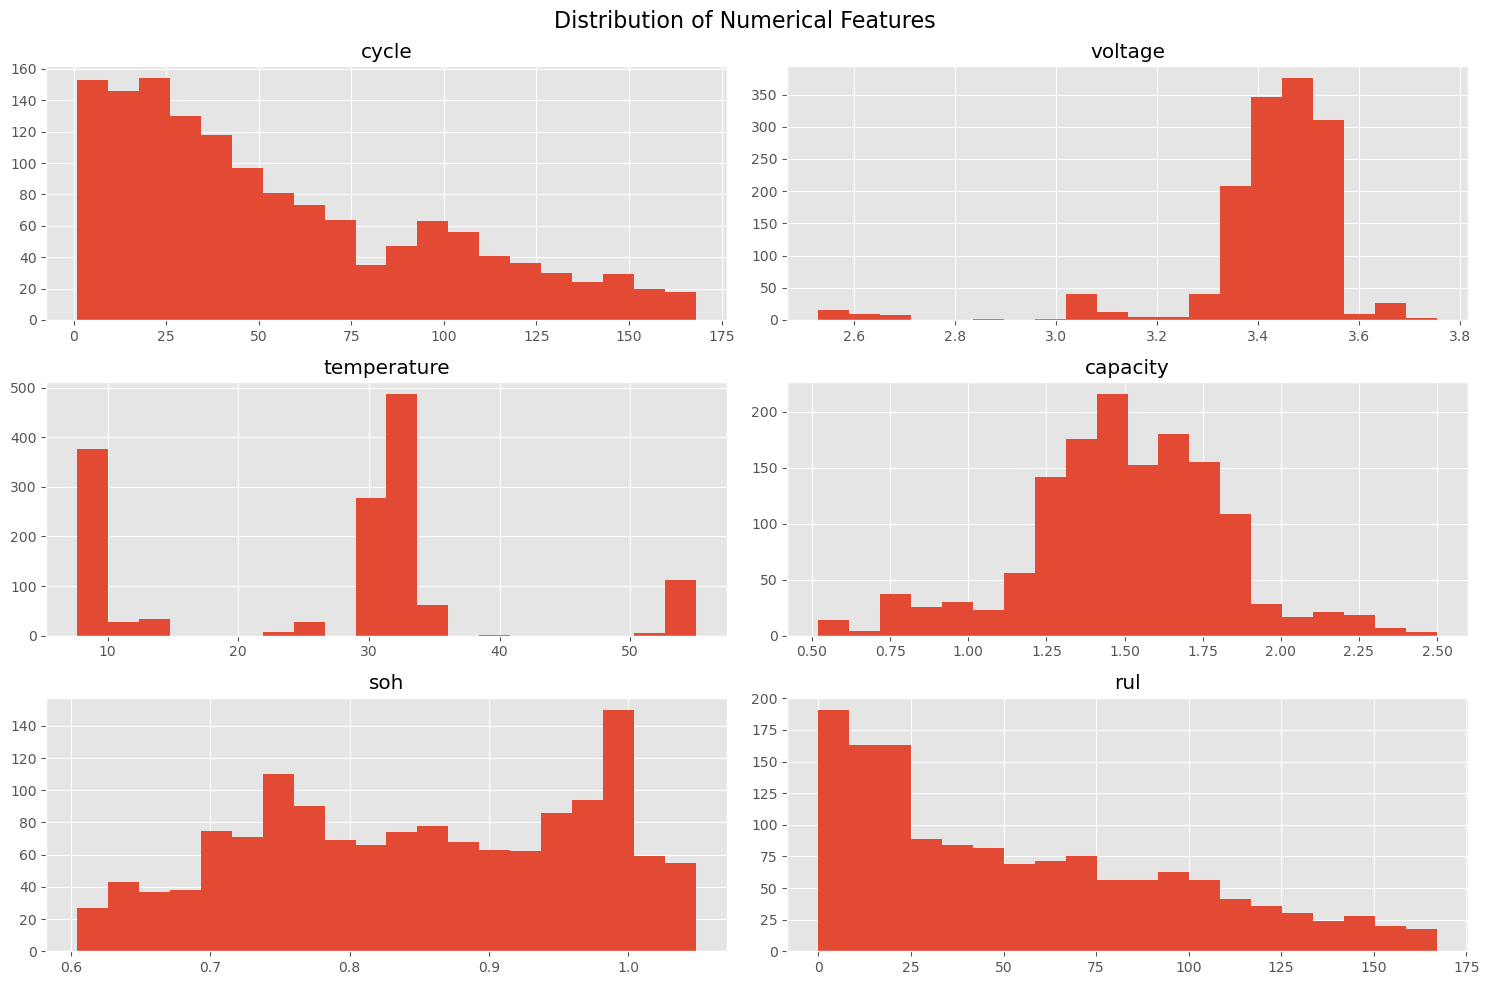

In [10]:
# Histogram for numerical feature
df.hist(figsize=(15, 10), bins=20)

plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

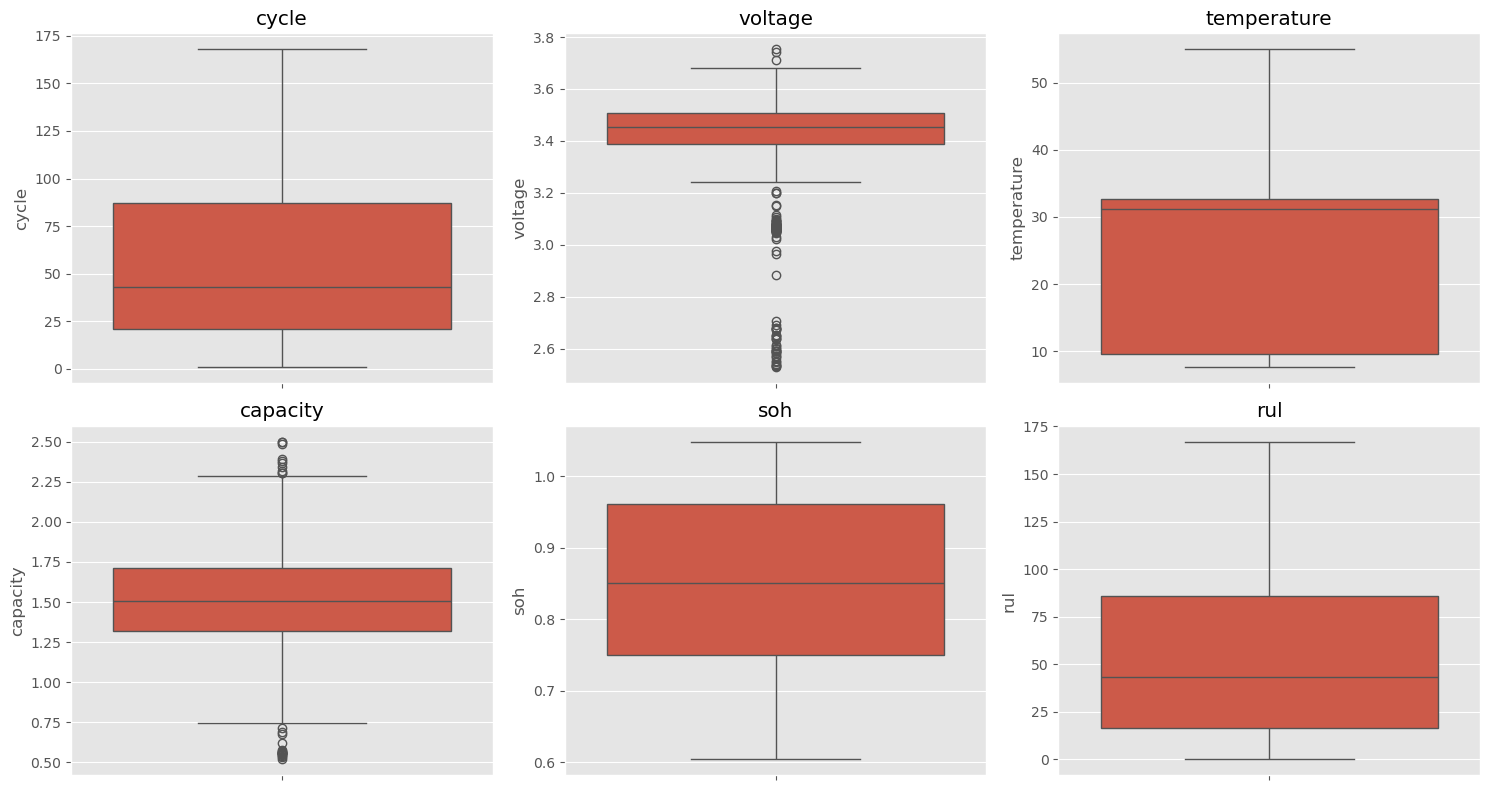

In [11]:
# Boxplots for Outlier Detection
plt.figure(figsize=(15, 8))

for i, column in enumerate(df.select_dtypes(include=["int64", "float64"]).columns, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[column])
    plt.title(column)

plt.tight_layout()
plt.show()

In [12]:
# Correlation matrix
corr_matrix = df.corr(numeric_only=True)

corr_matrix

,cycle,voltage,temperature,capacity,soh,rul
cycle,1.000000,0.036271,0.030307,-0.256151,-0.622161,-0.355340
voltage,0.036271,1.000000,0.249777,0.466416,0.257508,0.368511
temperature,0.030307,0.249777,1.000000,0.536293,0.418583,0.174537
capacity,-0.256151,0.466416,0.536293,1.000000,0.643486,0.448028
soh,-0.622161,0.257508,0.418583,0.643486,1.000000,0.332720
rul,-0.355340,0.368511,0.174537,0.448028,0.332720,1.000000


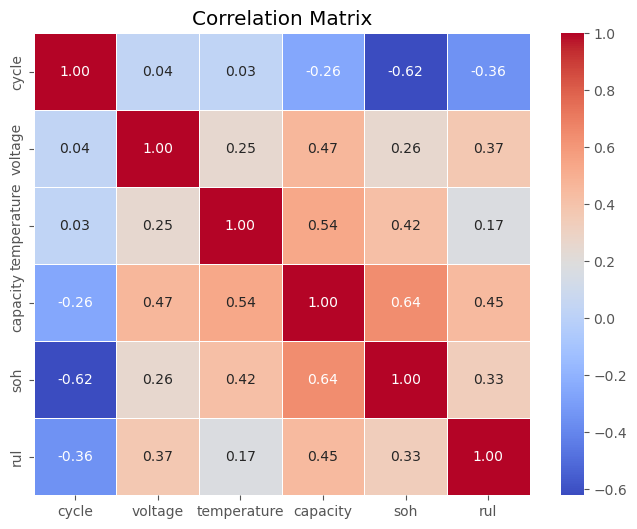

In [13]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix")
plt.show()

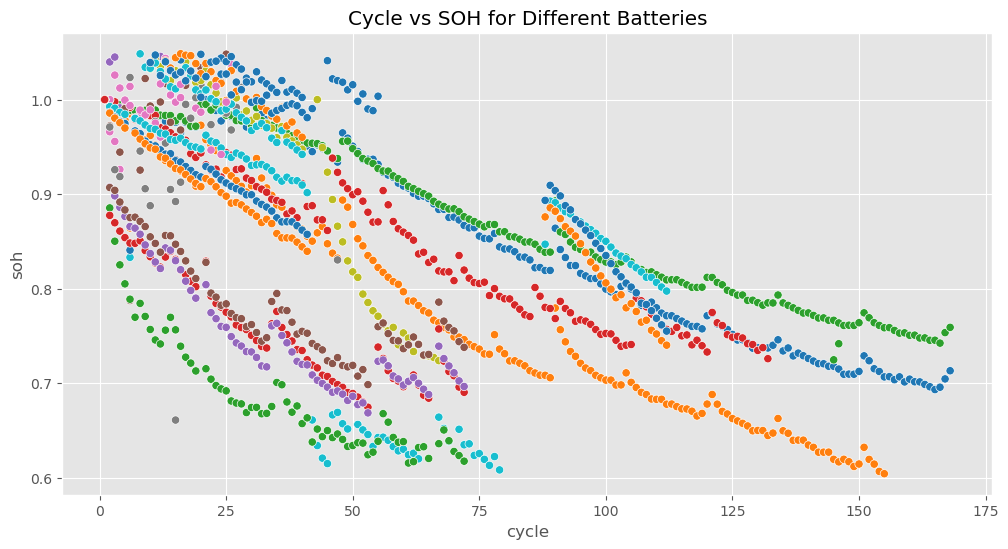

In [14]:
plt.figure(figsize=(12, 6))

sns.scatterplot(
    data=df,
    x="cycle",
    y="soh",
    hue="battery_id",
    palette="tab10",
    legend=False
) 

plt.title("Cycle vs SOH for Different Batteries")
plt.show()

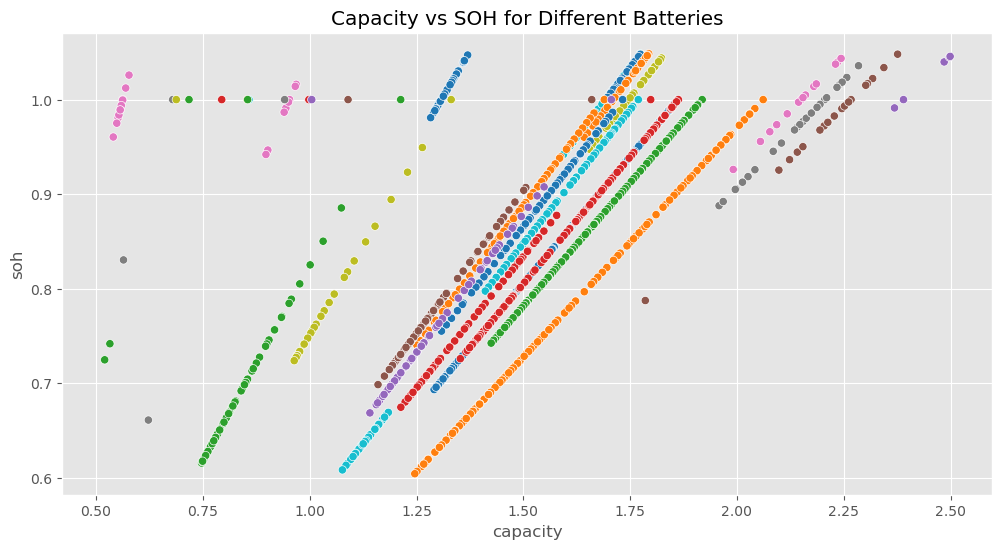

In [15]:
# Capacity vs SOH
plt.figure(figsize=(12, 6))

sns.scatterplot(
    data=df,
    x="capacity",
    y="soh",
    hue="battery_id",
    palette="tab10",
    legend=False
)

plt.title("Capacity vs SOH for Different Batteries")
plt.show()

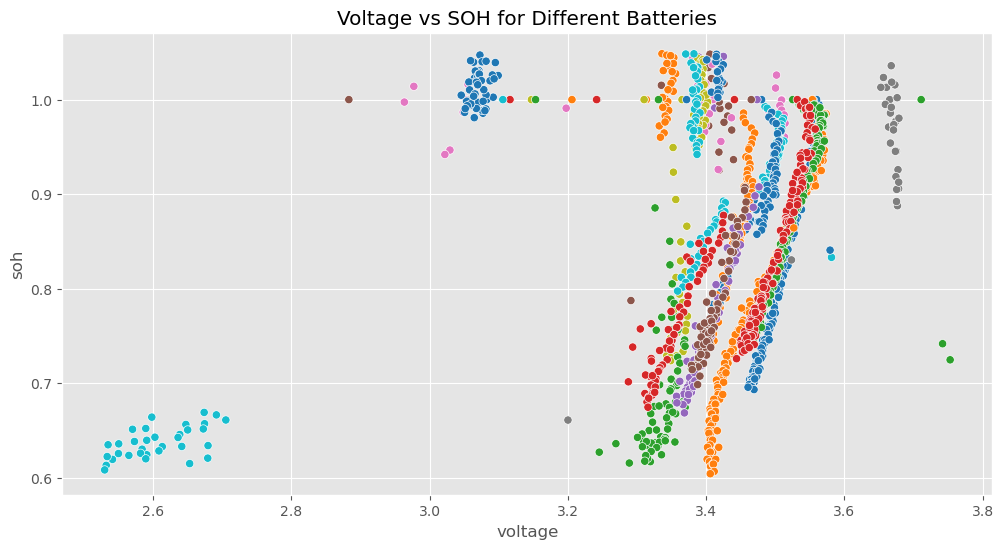

In [16]:
# Voltage vs SOH
plt.figure(figsize=(12, 6))

sns.scatterplot(
    data=df,
    x="voltage",
    y="soh",
    hue="battery_id",
    palette="tab10",
    legend=False
)

plt.title("Voltage vs SOH for Different Batteries")
plt.show()

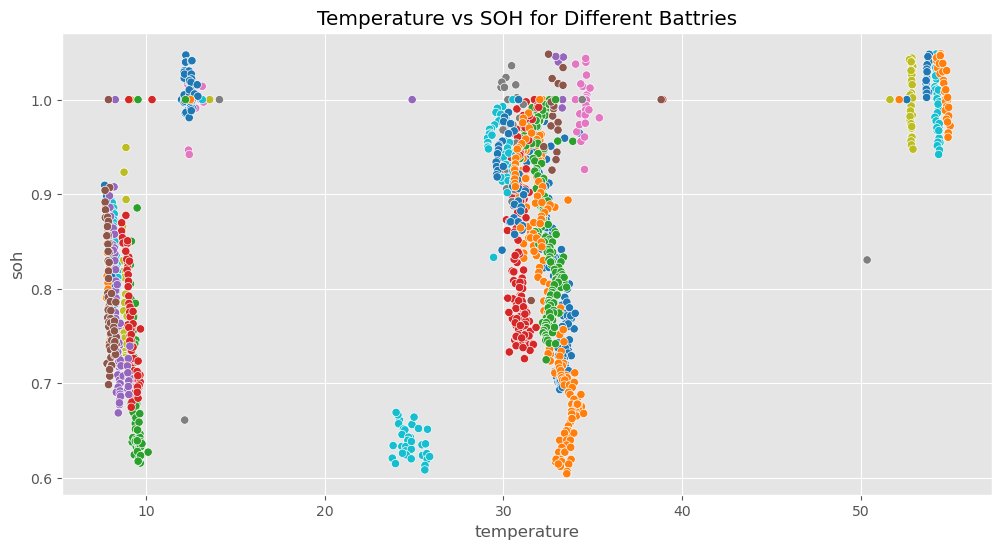

In [17]:
# Temperature vs SOH
plt.figure(figsize=(12, 6))

sns.scatterplot(
    data=df,
    x="temperature",
    y="soh",
    hue="battery_id",
    palette="tab10",
    legend=False
)

plt.title("Temperature vs SOH for Different Battries")
plt.show()

## Data Preprocessing

In [18]:
# Select input features
X = df[["cycle", "voltage", "temperature", "capacity"]]

# Target variable
y = df["soh"]


In [19]:
print("Features (X):")
print(X.head())

print("\nTarget (y):")
print(y.head())

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Features (X):
   cycle   voltage  temperature  capacity
0      1  3.532781    32.536891  1.861976
1      2  3.542968    32.643595  1.851862
2      3  3.553056    32.522526  1.840808
3      4  3.545849    32.492083  1.850058
4      5  3.544456    32.368612  1.849432

Target (y):
0    1.000000
1    0.994568
2    0.988631
3    0.993599
4    0.993263
Name: soh, dtype: float64

X shape: (1415, 4)
y shape: (1415,)


In [20]:
# Train-Test Split

from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [21]:
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)

print("\ny_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (1132, 4)
X_test shape : (283, 4)

y_train shape: (1132,)
y_test shape : (283,)


In [22]:
# Scaling 
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(X_train)

# Transform the training and testing data
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [23]:
# Verify the Result
print("Original Training Data")
print(X_train.head())

print("\nScaled Training Data:")
print(pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns
).head())

Original Training Data
     cycle   voltage  temperature  capacity
630      3  3.431176    32.755784  2.227847
767     34  3.419006    53.653553  1.713575
486    164  3.463949    32.371643  1.430435
48      49  3.562943    33.424519  1.786078
155    156  3.473257    33.084745  1.316545

Scaled Training Data:
      cycle   voltage  temperature  capacity
0 -1.217142  0.060112     0.471328  2.302332
1 -0.502034 -0.013125     2.053945  0.670805
2  2.496803  0.257323     0.442236 -0.227456
3 -0.156015  0.853016     0.521972  0.900820
4  2.312260  0.313332     0.496240 -0.588772


In [24]:
# Check mean and standard deviation after scaling
scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)

print("Mean after scaling:")
print(scaled_df.mean())

print("\nStandard deviation after scaling:")
print(scaled_df.std())

Mean after scaling:
cycle          2.196908e-17
voltage       -8.583632e-16
temperature   -8.238404e-17
capacity      -5.837498e-16
dtype: float64

Standard deviation after scaling:
cycle          1.000442
voltage        1.000442
temperature    1.000442
capacity       1.000442
dtype: float64


## Linear Regression

In [25]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[-0.06, 0. , 0.03, 0.05]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.8483
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,4
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](4,)","[46.11,34.75,29.14,18.59]"


In [26]:
print("Intercept:", lr_model.intercept_)

print("\nCoefficients:")

for feature, coef in zip(X.columns, lr_model.coef_):
    print(f"{feature}: {coef:.6f}")

Intercept: 0.8482838561131285

Coefficients:
cycle: -0.063591
voltage: 0.004847
temperature: 0.026103
capacity: 0.045443


In [27]:
# Make Predictions
# Predict SOH for the test data
y_pred = lr_model.predict(X_test_scaled)

In [28]:
# View Predictions
print("Predicted SOH:")
print(y_pred[:10])

print("\nActual SOH")
print(y_test.iloc[:10].values)

Predicted SOH:
[0.80585191 0.73606149 0.9736739  0.96487484 0.93673296 1.00135621
 0.90134689 0.8657706  0.75808744 0.90327308]

Actual SOH
[0.99950464 0.62574405 0.97734866 0.92496377 0.88632795 1.04852716
 0.88783516 0.88404949 0.87319245 0.9366823 ]


In [29]:
# Evaluate the Model

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE : 0.05336661549246722
MSE : 0.005261866188844721
RMSE: 0.07253872199621883
R2 Score: 0.6221143262812454


## Desicion Tree Regressor

In [30]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(
    random_state=42
)

# Train the model
dt_model.fit(X_train, y_train)

# Make predictions
y_pred_dt = dt_model.predict(X_test)


In [31]:
# Evaluate
mae_dt = mean_absolute_error(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree Result")
print("MAE :", mae_dt)
print("MSE :", mse_dt)
print("RMSE:", rmse_dt)
print("R2 Score:", r2_dt)

Decision Tree Result
MAE : 0.010273505581588233
MSE : 0.0006442134573922398
RMSE: 0.025381360432258943
R2 Score: 0.9537352285997976


## Random Forest

In [32]:
from sklearn.ensemble import RandomForestRegressor

In [33]:
# Create the Model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [34]:
# Train the Model
rf_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [35]:
# Make Predictions
y_pred_rf = rf_model.predict(X_test)

In [36]:
# Evaluation
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Result")
print("MAE :", mae_rf)
print("MSE :", mse_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)

Random Forest Result
MAE : 0.008256244173807279
MSE : 0.00035978349681623845
RMSE: 0.018967959743109917
R2 Score: 0.974161823161614


## Gradient Boosting Regressor

In [37]:
from sklearn.ensemble import GradientBoostingRegressor

In [38]:
# Create the Model
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

In [39]:
# Train the Model
gb_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf

In [40]:
# Make Predictions
y_pred_gb = gb_model.predict(X_test)

In [41]:
# Evaluate
mae_gb = mean_absolute_error(y_test, y_pred_gb)
mse_gb = mean_squared_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mse_gb)
r2_gb = r2_score(y_test, y_pred_gb)

print("Gradient Boosting Results")
print("MAE :", mae_gb)
print("MSE :", mse_gb)
print("RMSE:", rmse_gb)
print("R2 Score:", r2_gb)


Gradient Boosting Results
MAE : 0.017721725566485155
MSE : 0.0007521810238648164
RMSE: 0.027425918833556266
R2 Score: 0.9459814402798363


## XGBoost Regressor

In [42]:
!pip install xgboost

In [43]:
from xgboost import XGBRegressor

In [44]:
# Create the Model
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

In [45]:
# Train the Model
xgb_model.fit(X_train, y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [46]:
# Prediction
y_pred_xgb = xgb_model.predict(X_test)

In [47]:
# Evaluate

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost Result")
print("MAE :", mae_xgb)
print("MSE :", mse_xgb)
print("RMSE:", rmse_xgb)
print("R2 Score:", r2_xgb)

XGBoost Result
MAE : 0.01734304082537035
MSE : 0.0007013749593596206
RMSE: 0.026483484652885476
R2 Score: 0.9496301236985151


## Feature Importance

In [48]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
)

# Sort in descending order
feature_importance = feature_importance.sort_values(ascending=False)

print(feature_importance)

capacity       0.606647
cycle          0.175469
temperature    0.129381
voltage        0.088502
dtype: float64


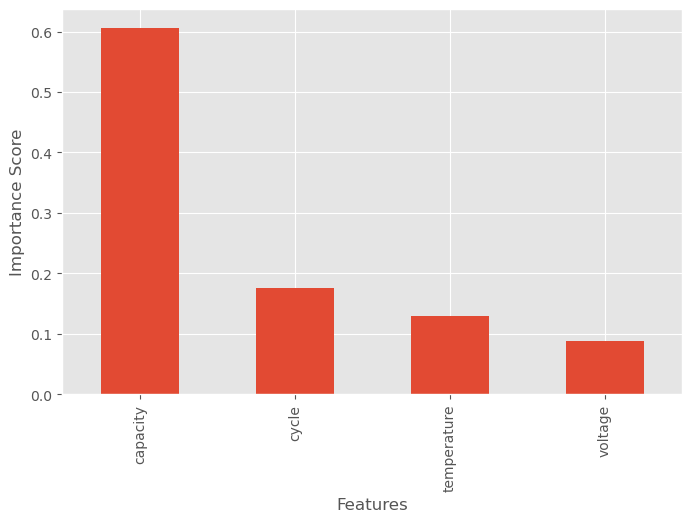

In [49]:
# Creat the Plot

plt.figure(figsize=(8,5))

feature_importance.plot(kind="bar")
plt.xlabel("Features")
plt.ylabel("Importance Score")

plt.show()

### Feature Importance Analysis:

The Random Forest model identified capacity as the most influential feature for predicting Battery State of Health (SOH), contributing approximately 60.66% of the total feature importance. This aligns with battery engineering principles, as SOH is closely related to the battery's remaining capacity. Cycle count was the second most important feature (17.55%), indicating that battery aging over repeated charge-discharge cycles significantly impacts SOH. Temperature (12.94%) also affected predictions, reflecting the influence of operating conditions on battery degradation. Voltage (8.85%) had the lowest importance, suggesting it contributed less to SOH prediction for this dataset.

In [50]:
# Import GroupKFold
from sklearn.model_selection import GroupKFold, cross_validate

In [51]:
group_kfold = GroupKFold(n_splits=5)

In [52]:
# Define Groups
groups = df["battery_id"]

In [53]:
# Cross-validation
scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2"
}

cv_results = cross_validate(
    rf_model,
    X,
    y,
    cv=group_kfold,
    groups=groups,
    scoring=scoring
)

In [54]:
print("GroupKFold Cross validation Results")

print("Average MAE :", -cv_results["test_MAE"].mean())
print("Average RMSE:", -cv_results["test_RMSE"].mean())
print("Average R2  :", cv_results["test_R2"].mean())

GroupKFold Cross validation Results
Average MAE : 0.05329066050717819
Average RMSE: 0.08397465161812712
Average R2  : 0.36016941963795734


In [55]:
print("MAE :", -cv_results["test_MAE"])
print("RMSE:", -cv_results["test_RMSE"])
print("R2  :", cv_results["test_R2"])

MAE : [0.02613785 0.02419752 0.05752921 0.08210164 0.07648707]
RMSE: [0.04341953 0.04303065 0.06835754 0.1351901  0.12987544]
R2  : [ 0.8112867   0.82391264  0.73976431 -0.70331195  0.12919539]


### GroupKFold Evaluation:

Since the dataset contains repeated measurements from only 34 batteries, GroupKFold was used to prevent data leakage by ensuring that all observations from the same battery remained in the same fold. The results showed that the model generalized well on some battery groups (R² ≈ 0.81) but performed poorly on others. This suggests that battery degradation patterns vary significantly between batteries. The limited number of unique batteries and the variability in degradation behavior likely contributed to the lower average GroupKFold performance.

## Hyperparameter Tuning

In [56]:
from sklearn.model_selection import GridSearchCV

In [57]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

In [58]:
# Create GridSearchCV
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

In [59]:
# Train the Grid Search
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,

In [60]:
# Display the Best Parameters
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross Validation R2:")
print(grid_search.best_score_)

Best Parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Best Cross Validation R2:
0.9629530559606228


In [61]:
best_rf = grid_search.best_estimator_

In [62]:
y_pred_best = best_rf.predict(X_test)

print("Random Forest After Hyperparameter Tuning")
print("MAE :", mean_absolute_error(y_test, y_pred_best))
print("MSE :", mean_squared_error(y_test, y_pred_best))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_best)))
print("R2:", r2_score(y_test, y_pred_best))
      

Random Forest After Hyperparameter Tuning
MAE : 0.008184249913405075
MSE : 0.0003498700655470945
RMSE: 0.018704813967187553
R2: 0.9748737651836189


### Hyperparameter Tuning:

GridSearchCV was used to optimize the Random Forest Regressor by searching over different values of n_estimators, max_depth, min_samples_split, and min_samples_leaf. The optimal configuration consisted of 200 trees, unrestricted tree depth, a minimum split size of 2, and a minimum leaf size of 1. After tuning, the model achieved an R² score of 0.9749, slightly improving over the baseline Random Forest model (R² = 0.9742). This indicates that the default model was already strong, but tuning provided a modest performance gain.

In [63]:
# Save the Model
import joblib

In [64]:
joblib.dump(best_rf, "battery_soh_model.pkl")

['battery_soh_model.pkl']

In [65]:
print("Model saved successfully!")

Model saved successfully!


In [66]:
# Load the Saved Model
loaded_model = joblib.load("battery_soh_model.pkl")

In [67]:
print(loaded_model)

RandomForestRegressor(n_estimators=200, random_state=42)


### Prediction on New Battery

In [68]:
# New Battery SOH
new_battery = pd.DataFrame({
    "cycle": [100],
    "voltage": [3.45],
    "temperature": [30],
    "capacity": [1.65]
})
new_battery

,cycle,voltage,temperature,capacity
0,100,3.45,30,1.65


In [69]:
predicted_soh = loaded_model.predict(new_battery)

print("New Battery Details")
print(new_battery)

print(f"\nPredicted Battery SOH: {predicted_soh[0] * 100:.2f}%")

if predicted_soh[0] >= 0.95:
    print("Battery Condition: Excellent")
elif predicted_soh[0] >= 0.80:
    print("Battery Condition: Good")
elif predicted_soh[0] >= 0.60:
    print("Battery Condition: Moderate")
else:
    print("Battery Condition: Poor")

New Battery Details
   cycle  voltage  temperature  capacity
0    100     3.45           30      1.65

Predicted Battery SOH: 81.66%
Battery Condition: Good


## Model Comparison

In [71]:
import pandas as pd

In [80]:
model_results = {
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost",
        "Random Forest (Tuned)"
    ],
    
    "MAE": [
        0.0534,
        0.0103,
        0.0083,
        0.0177,
        0.0173,
        0.0082
    ],
    
    "RMSE": [
         0.0725,
         0.0254,
         0.0190,
         0.0274,
         0.0265,
         0.0187
    ],
    
    "R2 Score": [
        0.6221,
        0.9537,
        0.9742,
        0.9460,
        0.9496,
        0.9749
    ]
}
        
        

In [81]:
comparison_df = pd.DataFrame(model_results)
comparison_df

,Model,MAE,RMSE,R2 Score
0,Linear Regression,0.0534,0.0725,0.6221
1,Decision Tree,0.0103,0.0254,0.9537
2,Random Forest,0.0083,0.0190,0.9742
3,Gradient Boosting,0.0177,0.0274,0.9460
4,XGBoost,0.0173,0.0265,0.9496
5,Random Forest (Tuned),0.0082,0.0187,0.9749


## Conclusion

In this project, a Machine Learning model was developed to predict the State of Health (SOH) of lithium-ion batteries using battery operational parameters such as cycle count, voltage, temperature, and capacity.

The dataset was explored through Exploratory Data Analysis (EDA), followed by data preprocessing and feature engineering to prepare the data for model training.

Five regression models were evaluated:

- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor
- Gradient Boosting Regressor
- XGBoost Regressor

Among all the models, the Random Forest Regressor achieved the best performance. After hyperparameter tuning using GridSearchCV, the model achieved:

- MAE: 0.0082
- RMSE: 0.0187
- R² Score: 0.9749

Feature importance analysis revealed that battery capacity was the most influential feature for predicting SOH, followed by cycle count, temperature, and voltage.

To evaluate the model more reliably, GroupKFold cross-validation was also performed to avoid data leakage caused by multiple observations from the same battery.

Finally, the trained model was saved using Joblib and successfully used to predict the SOH of a new battery, demonstrating a complete end-to-end machine learning workflow.

### Future Work

Possible future improvements include:

- Collect a larger and more diverse battery dataset.
- Include additional features such as State of Charge (SOC), current, and internal resistance.
- Explore deep learning models such as LSTM or GRU for sequential battery degradation data.
- Deploy the trained model using Streamlit or FastAPI.
- Extend the project to predict Battery Remaining Useful Life (RUL).